<a href="https://colab.research.google.com/github/Rangsima-Khiaorai/GE234-Basic-Programming/blob/main/Lab5_GE234_Rasterio_6706615165_%E0%B8%A3%E0%B8%B1%E0%B8%87%E0%B8%AA%E0%B8%B4%E0%B8%A1%E0%B8%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [ ]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "example.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


In [ ]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


In [ ]:

import numpy as np

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [ ]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [ ]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "boundary.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  




---



1. แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 9389, 'height': 112, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 98.57626837674204,
       0.0, -8.983152841195215e-05, 7.206375040735212)}


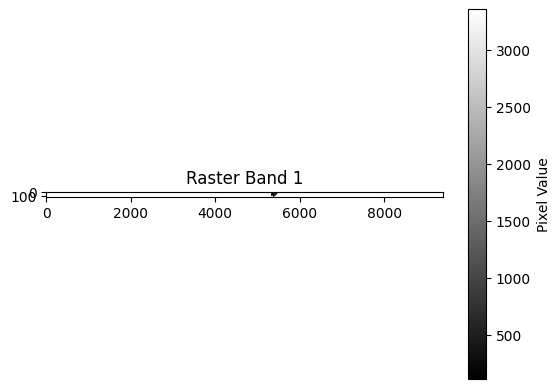

In [6]:
import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GE234/Krabi_Satellite_NDVI_Fixed-0000016384-0000000000.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

# แสดงผลด้วย Matplotlib
import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()




---



2. แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [8]:
import rasterio

# เปิดไฟล์ Raster เพื่อดึงข้อมูลเมตาอีกครั้ง (หากต้องการรันเซลล์นี้แยก)
raster_path = "/content/drive/MyDrive/GE234/Krabi_Satellite_NDVI_Fixed-0000016384-0000000000.tif"  # Path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    # ข้อมูลเมตาของภาพ Raster: dataset.meta

    # 'driver': 'GTiff' - รูปแบบของไฟล์ Raster (ในที่นี้คือ GeoTIFF)
    print(f"Driver: {dataset.driver}")

    # 'dtype': 'float32' - ชนิดข้อมูลของแต่ละพิกเซลในภาพ (เลขทศนิยม)
    print(f"Data Type: {dataset.meta['dtype']}")

    # 'nodata': None - ค่าสำหรับ 'ไม่มีข้อมูล' (NoData) ถ้ามีจะระบุค่าตัวเลข
    print(f"NoData Value: {dataset.nodata}")

    # 'width': 9389 - จำนวนคอลัมน์ของพิกเซล (ความกว้างของภาพ)
    print(f"Width (columns): {dataset.width}")

    # 'height': 112 - จำนวนแถวของพิกเซล (ความสูงของภาพ)
    print(f"Height (rows): {dataset.height}")

    # 'count': 4 - จำนวนแบนด์ (Band) หรือช่องสัญญาณในภาพ (มี 4 ชั้นข้อมูล)
    print(f"Number of Bands: {dataset.count}")

    # 'crs': CRS.from_wkt('GEOGCS["WGS 84",...]') - ระบบพิกัดอ้างอิง (WGS 84)
    print(f"Coordinate Reference System (CRS): {dataset.crs}")

    # 'transform': Affine(...) - เมทริกซ์การแปลงทางเรขาคณิต (ตำแหน่ง, ขนาดพิกเซล, จุดเริ่มต้น)
    print(f"Transform (Affine matrix): {dataset.transform}")

Driver: GTiff
Data Type: float32
NoData Value: None
Width (columns): 9389
Height (rows): 112
Number of Bands: 4
Coordinate Reference System (CRS): EPSG:4326
Transform (Affine matrix): | 0.00, 0.00, 98.58|
| 0.00,-0.00, 7.21|
| 0.00, 0.00, 1.00|


ไฟล์ Raster มีข้อมูลเมตา (Metadata) ที่สำคัญซึ่งให้รายละเอียดเกี่ยวกับคุณสมบัติของภาพ โดยจากข้อมูลเมตาที่ได้:  

*   **`driver`**: `'GTiff'` คือรูปแบบของไฟล์ Raster ซึ่งในที่นี้คือ GeoTIFF  
*   **`dtype`**: `'float32'` คือชนิดข้อมูลของแต่ละพิกเซลในภาพ ซึ่งเป็นเลขทศนิยมที่มีความแม่นยำสูง  
*   **`nodata`**: `None` หมายความว่าไม่ได้มีการกำหนดค่าสำหรับ 'ไม่มีข้อมูล' (NoData)  
*   **`width`**: `9389` คือจำนวนคอลัมน์ของพิกเซลในภาพ (ความกว้าง)  
*   **`height`**: `112` คือจำนวนแถวของพิกเซลในภาพ (ความสูง)  
*   **`count`**: `4` คือจำนวนแบนด์ (Band) หรือช่องสัญญาณในภาพ ซึ่งบ่งบอกว่าภาพนี้มี 4 ชั้นข้อมูล (เช่น แดง, เขียว, น้ำเงิน, NIR)  
*   **`crs`**: `CRS.from_wkt('GEOGCS["WGS 84",...]')` คือระบบพิกัดอ้างอิง (Coordinate Reference System) ของภาพ ซึ่งในที่นี้คือ WGS 84 เป็นระบบพิกัดทางภูมิศาสตร์ที่ใช้กันทั่วโลก  
*   **`transform`**: `Affine(...)` คือเมทริกซ์การแปลงทางเรขาคณิตที่อธิบายถึงตำแหน่งและขนาดของแต่ละพิกเซลในพิกัดทางภูมิศาสตร์ รวมถึงขนาดของพิกเซล (resolution) และจุดเริ่มต้นของภาพ



---



3. แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

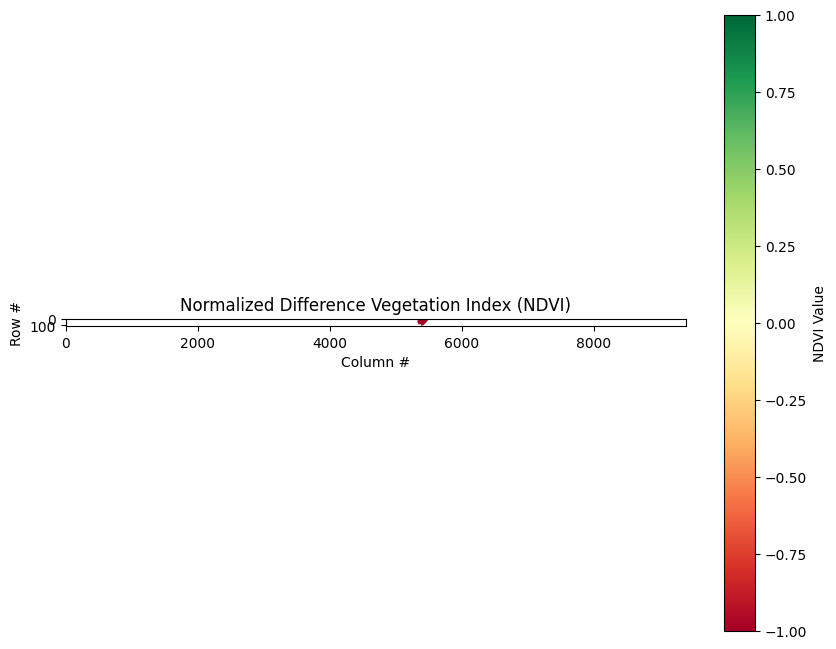

In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ใช้ raster_path ที่ถูกกำหนดไว้ก่อนหน้านี้
raster_path = "/content/drive/MyDrive/GE234/Krabi_Satellite_NDVI_Fixed-0000016384-0000000000.tif"
# **หมายเหตุ**: ไฟล์นี้อาจจะเป็นไฟล์ NDVI ที่คำนวณมาแล้ว
# ควรใช้ไฟล์ภาพดาวเทียมดิบที่มีแบนด์ Red และ NIR แยกกัน เพื่อคำนวณ NDVI

with rasterio.open(raster_path) as dataset:
    # ตรวจสอบจำนวนแบนด์ก่อนอ่าน เพื่อให้แน่ใจว่ามีแบนด์ที่ต้องการ
    if dataset.count < 4:
        print("ไฟล์ Raster มีจำนวนแบนด์ไม่เพียงพอสำหรับการคำนวณ NDVI (ต้องการอย่างน้อย 4 แบนด์สำหรับ Red และ NIR)")
    else:
        # อ่านแบนด์ NIR (เช่น Band 4) และ Red (เช่น Band 3)
        # ตรวจสอบลำดับแบนด์ของภาพดาวเทียมของคุณเสมอ
        nir = dataset.read(4).astype(float)  # สมมติว่า Band 4 คือ NIR
        red = dataset.read(3).astype(float)  # สมมติว่า Band 3 คือ Red

        # จัดการค่า NaN/NoData (หากมี) เพื่อหลีกเลี่ยงการคำนวณผิดพลาด
        # แทนที่ค่า NoData ด้วย NaN เพื่อให้ NumPy จัดการได้ง่ายขึ้น
        if dataset.nodata is not None:
            nir[nir == dataset.nodata] = np.nan
            red[red == dataset.nodata] = np.nan

        # คำนวณ NDVI
        # เพิ่ม 1e-10 เพื่อหลีกเลี่ยงการหารด้วยศูนย์
        ndvi = (nir - red) / (nir + red + 1e-10)

        # แสดงผล NDVI
        plt.figure(figsize=(10, 8))
        plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
        plt.colorbar(label="NDVI Value")
        plt.title("Normalized Difference Vegetation Index (NDVI)")
        plt.xlabel("Column #")
        plt.ylabel("Row #")
        plt.show()




---



4. แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

In [11]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "/content/drive/MyDrive/GE234/Thailand/Thailand/Province.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")

ValueError: Input shapes do not overlap raster.



---



จัดทำโดย : นางสาวรังสิมา เขียวร้าย 6706615165